# 8.6 Comparing Clustering Methods

### 8.6.1 CASE STUDY

8.6.1.1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gmpy2 import random_state
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "2"


import os

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "2"

Import the data and perform initial analysis

In [2]:
penguins = sns.load_dataset("penguins")

In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
penguins.shape

(344, 7)

In [7]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [8]:
penguins_clean = penguins.dropna()

penguins_clean= pd.get_dummies(penguins_clean, columns = ['species', 'island', 'sex'], drop_first=True)

# extract feature column for clustering
X = penguins_clean.drop('species_Chinstrap', axis = 1)

In [9]:
# penguins_clean

### Clustering with Partitioning Methods (K-Means)

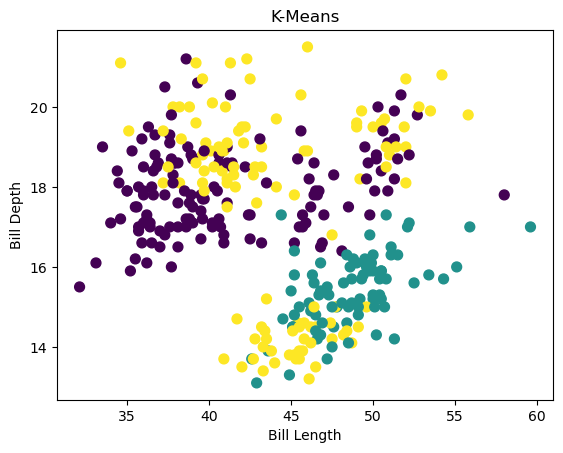

Silhouette Score:  0.5589143543024182


In [10]:
from sklearn.cluster import  KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")

kmeans_labels = kmeans.fit_predict(X)

# plots

plt.scatter(X['bill_length_mm'], X['bill_depth_mm'], c=kmeans_labels, cmap='viridis', s=50)
plt.title('K-Means')
plt.xlabel('Bill Length')
plt.ylabel('Bill Depth')
plt.show()

#print scores
silhouette_score_kmeans = silhouette_score(X, kmeans_labels)
print('Silhouette Score: ', silhouette_score_kmeans)    

### Clustering with Hierarchial Clustering

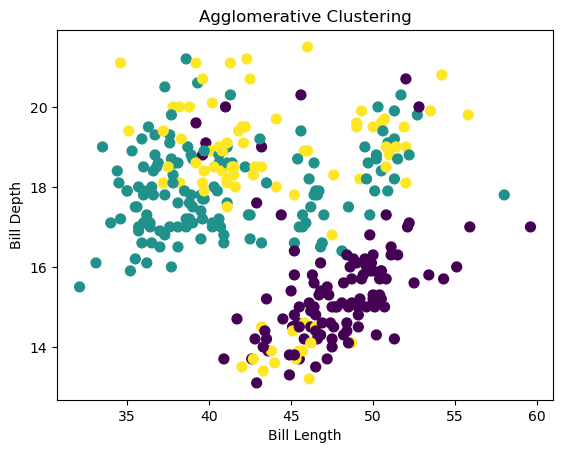

Silhouette Score:  0.5164048191027537


In [12]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X)

#plot

plt.scatter(X['bill_length_mm'], X[ 'bill_depth_mm'], c=agg_labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering")
plt.xlabel("Bill Length")
plt.ylabel("Bill Depth")
plt.show()  

silhouette_score_agg = silhouette_score(X, agg_labels)
print('Silhouette Score: ', silhouette_score_agg)   

### Clustering with Density-Based Algorithms

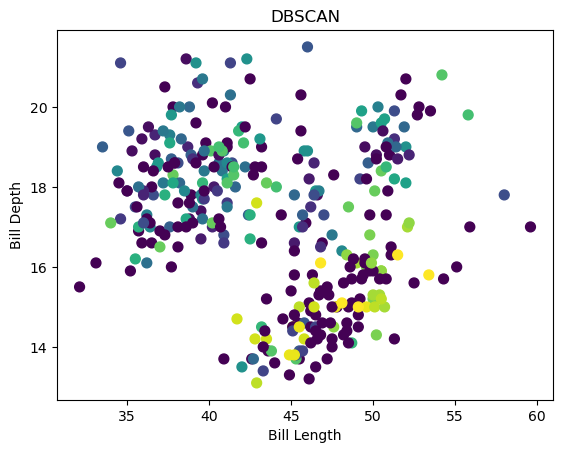

Silhouette Score:  0.10544174253690712


In [13]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=20, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

#plot

plt.scatter(X['bill_length_mm'], X['bill_depth_mm'], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN')
plt.xlabel('Bill Length')
plt.ylabel('Bill Depth')
plt.show()

silhouette_score_dbscan = silhouette_score(X, dbscan_labels)
print('Silhouette Score: ', silhouette_score_dbscan)

### Compare Clustering Methods and Conclusion

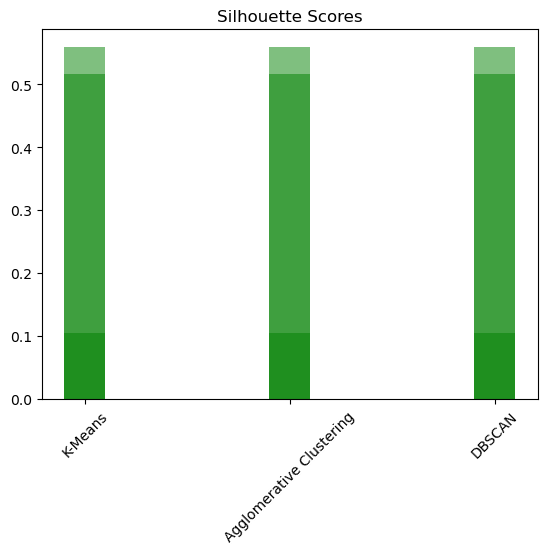

Silhouette Score for K-Means: 0.55891.
Silhouette Score for Agglomerative Clustering: 0.51640.
Silhouette Score for DBSCAN: 0.10544.


In [18]:
silhouette_scores = [silhouette_score_kmeans, silhouette_score_agg, silhouette_score_dbscan]
names = ['K-Means', 'Agglomerative Clustering', 'DBSCAN']

for i, score in enumerate(silhouette_scores):
    plt.bar(names, score, color='g', alpha=0.5, width=0.2)
plt.xticks(rotation=45)
plt.title('Silhouette Scores')
plt.show()

for i, score in enumerate(silhouette_scores):
    print(f'Silhouette Score for {names[i]}: {score:.5f}.')
